Libraries Imported Successfully
Using Colab cache for faster access to the 'california-housing-prices' dataset.
Dataset Downloaded
/kaggle/input/california-housing-prices
CSV File Found
/kaggle/input/california-housing-prices/housing.csv

First Five Rows
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            35210

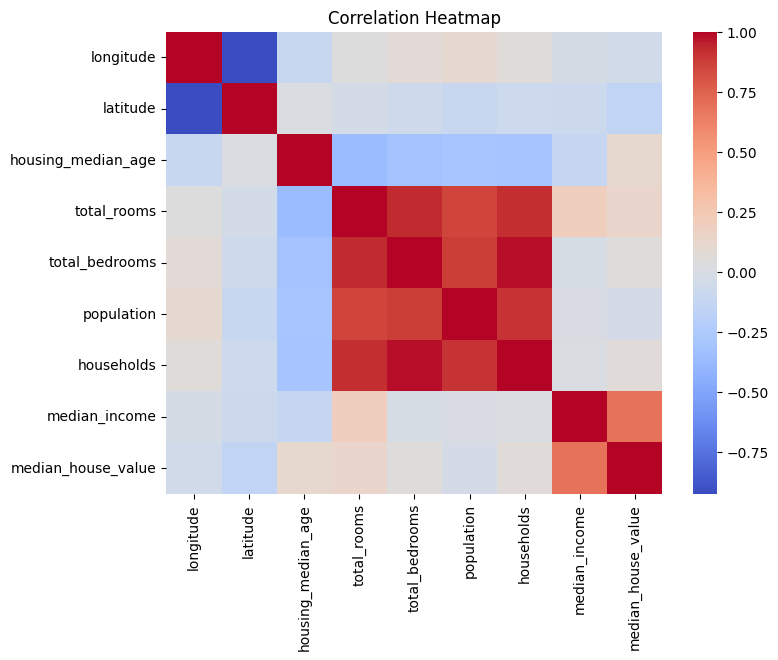

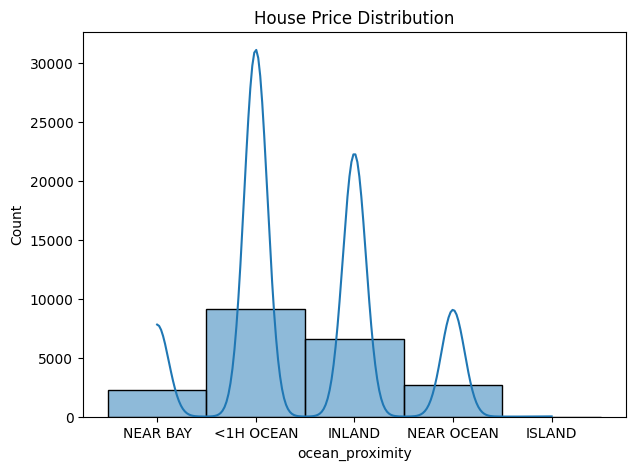


Target Column : ocean_proximity
Duplicate Rows : 0
Duplicates Removed Successfully

Missing Values After Cleaning
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Shape After Removing Outliers
(16896, 10)

Categorical Encoding Completed

Target Column : ocean_proximity

Feature Columns
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

Training Shape
(13516, 9)

Testing Shape
(3380, 9)

Preprocessing Completed Successfully
LINEAR REGRESSION RESULTS
MAE : 1.0261526430113608
MSE : 1.6711073283740505
RMSE : 1.2927131655452615
R2 Score : 0.14119305761113066


RANDOM FOREST RESULTS
MAE : 0.08543491124260355
MSE : 0.13289281065088757
RMSE : 0.36454466

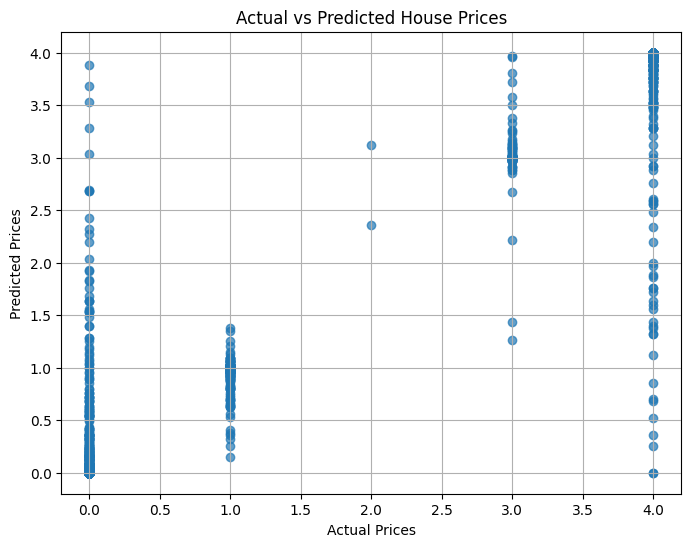

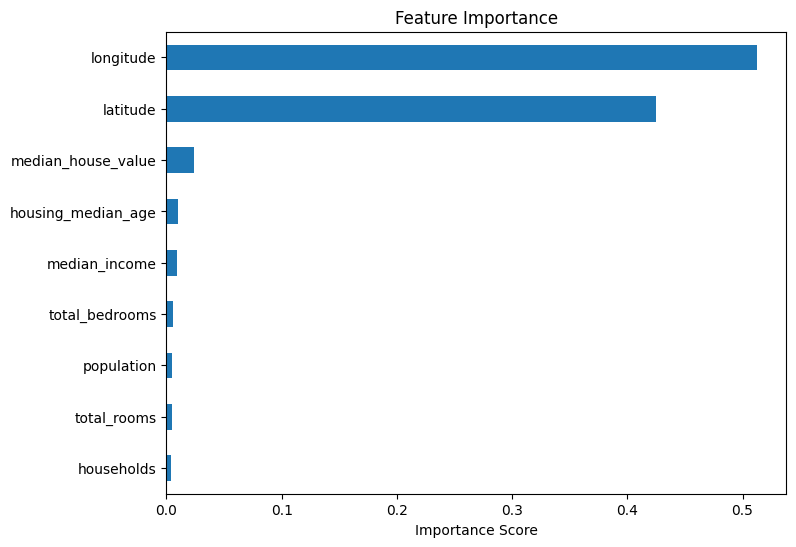


Sample Predictions
   Actual Price  Predicted Price
0             1             1.00
1             0             0.00
2             0             0.00
3             1             1.00
4             1             0.96
5             3             3.00
6             0             0.00
7             4             3.97
8             0             0.00
9             4             4.00


HOUSE PRICE PREDICTION PROJECT COMPLETED
Algorithms Used:
1. Linear Regression
2. Random Forest Regressor

Evaluation Metrics:
- MAE
- MSE
- RMSE
- R2 Score

Graphs Generated:
- Correlation Heatmap
- Price Distribution
- Income vs Price
- Actual vs Predicted
- Feature Importance

SUCCESSFULLY COMPLETED!


In [3]:
# ==========================================
# HOUSE PRICE PREDICTION
# PART 1
# OPTIMUS AUTOMATE
# ==========================================

# Install required libraries
!pip install kagglehub -q

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

print("Libraries Imported Successfully")

# ==========================================
# Download Kaggle Dataset
# ==========================================

path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Dataset Downloaded")

print(path)

# ==========================================
# Find CSV File
# ==========================================

csv_file = None

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)

print("CSV File Found")

print(csv_file)

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(csv_file)

print("\nFirst Five Rows")

print(df.head())

print("\nShape")

print(df.shape)

print("\nInformation")

print(df.info())

print("\nMissing Values")

print(df.isnull().sum())

# ==========================================
# Exploratory Data Analysis
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# ==========================================
# House Price Distribution
# ==========================================

target_column = df.columns[-1]

plt.figure(figsize=(7,5))

sns.histplot(df[target_column],
             bins=30,
             kde=True)

plt.title("House Price Distribution")

plt.show()

print("\nTarget Column :", target_column)
# ==========================================
# HOUSE PRICE PREDICTION
# PART 2A
# Data Cleaning & Preprocessing
# ==========================================

# -------------------------------
# Remove Duplicate Rows
# -------------------------------

print("Duplicate Rows :", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates Removed Successfully")

# -------------------------------
# Handle Missing Values
# -------------------------------

numeric_columns = df.select_dtypes(include=['int64','float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

# Fill Numeric Missing Values

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill Categorical Missing Values

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Cleaning")

print(df.isnull().sum())

# -------------------------------
# Remove Outliers (IQR Method)
# -------------------------------

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("\nShape After Removing Outliers")

print(df.shape)

# -------------------------------
# Encode Categorical Columns
# -------------------------------

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in categorical_columns:

    df[col] = encoder.fit_transform(df[col])

print("\nCategorical Encoding Completed")

# -------------------------------
# Feature Selection
# -------------------------------

target_column = df.columns[-1]

X = df.drop(target_column, axis=1)

y = df[target_column]

print("\nTarget Column :", target_column)

print("\nFeature Columns")

print(X.columns)

# -------------------------------
# Train Test Split
# -------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

print("\nTraining Shape")

print(X_train.shape)

print("\nTesting Shape")

print(X_test.shape)

print("\nPreprocessing Completed Successfully")
# ==========================================
# HOUSE PRICE PREDICTION
# PART 2B
# Model Training & Evaluation
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

# ==========================================
# Linear Regression
# ==========================================

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_prediction = linear_model.predict(X_test)

print("="*60)
print("LINEAR REGRESSION RESULTS")
print("="*60)

print("MAE :", mean_absolute_error(y_test, linear_prediction))
print("MSE :", mean_squared_error(y_test, linear_prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, linear_prediction)))
print("R2 Score :", r2_score(y_test, linear_prediction))

# ==========================================
# Random Forest Regressor
# ==========================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

print("\n")
print("="*60)
print("RANDOM FOREST RESULTS")
print("="*60)

print("MAE :", mean_absolute_error(y_test, rf_prediction))
print("MSE :", mean_squared_error(y_test, rf_prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_prediction)))
print("R2 Score :", r2_score(y_test, rf_prediction))

# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "MAE":[
        mean_absolute_error(y_test, linear_prediction),
        mean_absolute_error(y_test, rf_prediction)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test, linear_prediction)),
        np.sqrt(mean_squared_error(y_test, rf_prediction))
    ],

    "R2 Score":[
        r2_score(y_test, linear_prediction),
        r2_score(y_test, rf_prediction)
    ]

})

print("\n")
print("="*60)
print("MODEL COMPARISON")
print("="*60)

print(comparison)

# ==========================================
# Prediction vs Actual Plot
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_prediction,
    alpha=0.7
)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.show()

# ==========================================
# Feature Importance
# ==========================================

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values()

plt.figure(figsize=(8,6))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()

# ==========================================
# Sample Predictions
# ==========================================

results = pd.DataFrame({

    "Actual Price": y_test.values,

    "Predicted Price": rf_prediction

})

print("\nSample Predictions")

print(results.head(10))

# ==========================================
# Final Message
# ==========================================

print("\n")
print("="*70)
print("HOUSE PRICE PREDICTION PROJECT COMPLETED")
print("="*70)

print("Algorithms Used:")
print("1. Linear Regression")
print("2. Random Forest Regressor")

print("\nEvaluation Metrics:")
print("- MAE")
print("- MSE")
print("- RMSE")
print("- R2 Score")

print("\nGraphs Generated:")
print("- Correlation Heatmap")
print("- Price Distribution")
print("- Income vs Price")
print("- Actual vs Predicted")
print("- Feature Importance")

print("\nSUCCESSFULLY COMPLETED!")
print("="*70)
